![a3uAqnb.png](https://i.imgur.com/RsaUFvd.png)

# Recurrent Neural Networks from Scratch (real scratch)
### Vanilla RNN + Backpropagation Through Time, in pure NumPy

We build a sentiment classifier for movie reviews **without any deep learning framework**.
No PyTorch, no TensorFlow, no autograd. Every gradient is derived and written by hand.

**Agenda:**

| Part | Topic |
|---|---|
| 1 | Load and explore the data |
| 2 | Text → numbers (tokenizing, vocabulary, padding) |
| 3 | The RNN forward pass |
| 4 | Backpropagation Through Time, derived and implemented |
| 5 | Gradient checking (proving our math is right) |
| 6 | The training loop |
| 7 | Visualizing what the model learned |

**Dataset:** [IMDB 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews).
Dataset is simple, movie reviews with the their sentiment classified either positive or negitive

## Part 0 — Setup

Only NumPy and Matplotlib. That's the whole stack.

In [5]:
import re, os, time
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

# set seed
rng = np.random.default_rng(0)

# how output looks
np.set_printoptions(precision=3, suppress=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

### Configuration

Everything tunable lives here. Shrink `N_TRAIN` or `EPOCHS` if you're short on time
during the lesson — the whole notebook is designed to train in a couple of minutes.

In [6]:
CSV_PATH  = "IMDB Dataset.csv"

VOCAB_SIZE = 5000*2    # keep the most frequent words only
MAX_LEN    = 120       # truncate/pad every review to this many tokens
EMBED_DIM  = 50        # size of each word vector
HIDDEN_DIM = 64        # size of the RNN memory (hidden state)
N_TRAIN    = 10_000    # subsample: pure NumPy is slow, we don't need all 50k to prove it works
N_TEST     = 2500

EPOCHS        = 10
BATCH_SIZE    = 64
LEARNING_RATE = 2e-3
CLIP_NORM     = 1

## Part 1 — The data

Each row is a review and a label: `positive` or `negative`. The split is 50/50,
so a coin flip gets 50% and anything above that is real learning.

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [8]:
import pandas as pd
df = pd.read_csv(os.path.join(path, CSV_PATH))
reviews, sentiments = df["review"].tolist(), df["sentiment"].tolist()

labels = np.array([1.0 if s == "positive" else 0.0 for s in sentiments])

print(f"reviews : {len(reviews)}")
print(f"positive: {labels.mean():.1%}")
df.head()

reviews : 50000
positive: 50.0%


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Part 2 — Turning text into numbers

A neural network eats vectors, not strings. Three steps:

1. **Tokenize** — strip HTML, lowercase, split into words.
2. **Build a vocabulary** — map each of the `VOCAB_SIZE` most common words to an integer id.
   Two ids are reserved: `0 = <pad>` and `1 = <unk>` (any word outside the vocabulary).
3. **Pad to a fixed length** — so we can process a whole batch as one array.

### Why we need a mask

Reviews have different lengths, but our arrays are rectangular. Short reviews get padded
with zeros at the end. We must not let those fake tokens change the model's memory / calculate gradients on

so we have a mask no each input, 1 for actual input 0 for paddings, we use the zeros to multiply and remove gradient calculations of padding tokens later on

In [9]:
TOKEN_RE = re.compile(r"[a-z']+")

def tokenize(text):
    text = re.sub(r"<[^>]+>", " ", text.lower())   # kill <br /> tags
    return TOKEN_RE.findall(text)

docs = [tokenize(t) for t in reviews]

counts = Counter(w for d in docs for w in d)
itos   = ["<pad>", "<unk>"] + [w for w, _ in counts.most_common(VOCAB_SIZE - 2)]
stoi   = {w: i for i, w in enumerate(itos)}
V      = len(itos)              # actual vocab size (may be < VOCAB_SIZE on small corpora)

print("total tokens :", sum(len(d) for d in docs))
print("unique words :", len(counts))
print("vocab kept   :", len(itos))
print("most common  :", itos[2:12])
print("\ntokenized example:", docs[0][:20])

total tokens : 11488257
unique words : 119364
vocab kept   : 10000
most common  : ['the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this']

tokenized example: ['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'oz', 'episode', "you'll", 'be', 'hooked', 'they', 'are', 'right', 'as']


In [10]:
def encode(doc):
    """tokens -> (padded id vector, mask vector)"""
    ids  = [stoi.get(w, 1) for w in doc[:MAX_LEN]]
    n    = len(ids)
    pad  = [0] * (MAX_LEN - n)
    mask = [1.0] * n + [0.0] * (MAX_LEN - n)
    return ids + pad, mask

X = np.zeros((len(docs), MAX_LEN), dtype=np.int32)    # token ids
M = np.zeros((len(docs), MAX_LEN), dtype=np.float64)  # 1 = real token, 0 = padding

for i, d in enumerate(docs):
    X[i], M[i] = encode(d)

print("X shape:", X.shape, " M shape:", M.shape)
print("\nfirst 15 ids of review 0 :", X[0, :15])
print("decoded                  :", [itos[i] for i in X[0, :15]])
print("review 0 real length     :", int(M[0].sum()), "tokens")

X shape: (50000, 120)  M shape: (50000, 120)

first 15 ids of review 0 : [  27    5    2   79 2081   45 1064   12  100  147   39 3134  396  472
   26]
decoded                  : ['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'oz', 'episode', "you'll", 'be']
review 0 real length     : 120 tokens


I'll use GloVe for simplicity, originally I trained embeddings end-to-end, replaced them with GloVe just to simplify the gradients

In [67]:
import urllib.request
import zipfile

# Download GloVe 6B
print("Downloading GloVe embeddings...")
url = "https://nlp.stanford.edu/data/glove.6B.zip"
extract_dir = "glove_data"
zip_file = "glove.6B.zip"

if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)
    if not os.path.exists(zip_file):
        urllib.request.urlretrieve(url, zip_file)
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

def load_glove(path, dim, word_to_idx):
    embedding_matrix = np.zeros((len(word_to_idx), dim))
    found = 0
    if not os.path.exists(path):
        raise FileNotFoundError(f"GloVe file not found at {path}. Use dim 50, 100, 200, or 300.")
    with open(path, "r", encoding="utf8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            if word in word_to_idx:
                vector = np.asarray(values[1:], dtype="float32")
                embedding_matrix[word_to_idx[word]] = vector
                found += 1
    print(f"Loaded {found} words from GloVe into embedding matrix")
    return embedding_matrix

# Now EMBED_DIM is 50, so this path will exist
GLOVE_PATH = os.path.join(extract_dir, f"glove.6B.{EMBED_DIM}d.txt")
embedding_matrix = load_glove(GLOVE_PATH, EMBED_DIM, stoi)

Loaded 9826 words from GloVe into embedding matrix


### Train / test split

In [81]:
perm = rng.permutation(len(X))
X, M, y = X[perm], M[perm], labels[perm]

# clamp to what's actually available, so any dataset size works
n_train = min(N_TRAIN, int(0.8 * len(X)))
n_test  = min(N_TEST, len(X) - n_train)

X_train, M_train, y_train = X[:n_train], M[:n_train], y[:n_train]
X_test,  M_test,  y_test  = X[n_train:n_train + n_test], M[n_train:n_train + n_test], y[n_train:n_train + n_test]

print(f"train: {X_train.shape}  positive {y_train.mean():.1%}")
print(f"test : {X_test.shape}  positive {y_test.mean():.1%}")

train: (10000, 120)  positive 49.5%
test : (2500, 120)  positive 51.0%


## Part 3 — The model

A vanilla RNN reads one word at a time and maintains a **hidden state** $h$ fixed-size vector
that is its entire memory of everything read so far.

$$h_t = \tanh(x_t W_x + h_{t-1} W_h + b), \qquad h_0 = \mathbf{0}$$

where $x_t$ is the embedding of word $t$. the same weights $W_x, W_h, b$ are reused at each time step cause it's an RNN.

After the last word we read the final hidden state and squeeze it into one number (a latent space of all time steps z):

$$z = h_T W_y + b_y, \qquad p = \sigma(z) = \frac{1}{1 + e^{-z}}$$

$p$ is the predicted probability the review is positive. We train with binary cross-entropy:

$$\mathcal{L} = -\big[y \log p + (1 - y)\log(1 - p)\big]$$

### The parameters

| Name | Shape | Role |
|---|---|---|
| `Wx` | (D, H) | how the current word updates the state |
| `Wh` | (H, H) | how the previous state carries forward |
| `b`  | (H,)   | bias |
| `Wy` | (H, 1) | readout from final state to a logit |
| `by` | (1,)   | output bias |


Note: Weights are scaled by $1/\sqrt{\text{fan-in}}$ so activations start in the useful part of
$\tanh$ instead of saturating at $\pm 1$.

In [11]:
def init_params(vocab=V, D=EMBED_DIM, H=HIDDEN_DIM, seed=0):
    r = np.random.default_rng(seed)
    return {
        # xavier initialization; you can try other initlizations
        # or make your own ! try uniform or all zeros !
        "Wx": r.normal(0, 1 / np.sqrt(D), (D, H)),
        "Wh": r.normal(0, 1 / np.sqrt(H), (H, H)),
        "b":  np.zeros(H),
        "Wy": r.normal(0, 1 / np.sqrt(H), (H, 1)),
        "by": np.zeros(1),
    }

### Forward pass

We loop over time, but **not** over the batch: we handle all inputs in the batch at time=t in one advance, meaning we handle each word of time=t in the batch at one step at a time as a matrix multiply. That's what makes pure NumPy fast enough here.

We stpre two things per timestep for the backward pass (we'll need them for gradients):
- `h_raw[t]` — the $\tanh$ output *before* masking (needed for the $1 - \tanh^2$ derivative)
- `h[t]` — the state *after* masking (what actually got carried forward)

In [70]:
# Activation function
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

def forward(p, x_batch, mask_batch, embedding_matrix):
    """
    x_batch          : (B, T) int ids
    mask_batch       : (B, T) 1 real / 0 padding
    embedding_matrix : (V, D) Pre-trained embeddings (e.g. GloVe)
    returns          : logits (B,), plus a cache for backprop
    """
    B, T = x_batch.shape
    emb = embedding_matrix[x_batch]                 # (B, T, D) | embed words

    h      = np.zeros((B, p["Wh"].shape[0]))        # initlize hidden state
    h_list = [h]      # h_list[t] is the state BEFORE reading word t
    h_raw  = []       # pre-mask tanh output at each step

    # from time=1 -> t
    for t in range(T):
        # aₜ = xₜWₓ + hₜ₋₁Wₕ + b
        a  = emb[:, t] @ p["Wx"] + h @ p["Wh"] + p["b"]

        # hₜ = tanh(aₜ)
        hr = np.tanh(a)

        m  = mask_batch[:, t][:, None]
        h  = m * hr + (1 - m) * h          # padding => keep the old state unchanged

        h_raw.append(hr)
        h_list.append(h)

    # z = hₜ * Wᵧ + bᵧ
    logits = (h @ p["Wy"] + p["by"]).ravel()
    # store them
    cache  = (x_batch, mask_batch, emb, h_list, h_raw)
    return logits, cache

def bce_loss(logits, targets):
    p = sigmoid(logits)
    loss = -np.mean(targets * np.log(p + 1e-9) + (1 - targets) * np.log(1 - p + 1e-9))
    # dloss/dz, beautifully simple
    dlogits = (p - targets) / len(targets)
    return loss, dlogits

## Part 4 — Backpropagation Through Time

Here's the whole idea. Unroll the RNN and it becomes a very deep feed-forward network,
$T$ layers tall, where **every layer shares the same weights**. Backprop still works, we
just have to accumulate the gradient of $W_x, W_h, b$ across all $T$ steps instead of once.

Start at the output and work backwards:

$$\frac{\partial \mathcal{L}}{\partial z} = p - y \qquad
\frac{\partial \mathcal{L}}{\partial W_y} = h_T^\top \frac{\partial \mathcal{L}}{\partial z} \qquad
\frac{\partial \mathcal{L}}{\partial h_T} = \frac{\partial \mathcal{L}}{\partial z} W_y^\top$$

Then step backwards through time. At step $t$, with $a_t$ the pre-activation and $\tanh' = 1 - \tanh^2$:

$$\delta_t = \frac{\partial \mathcal{L}}{\partial h_t} \odot m_t \odot (1 - h^{\text{raw}\,2}_t)$$

$$\frac{\partial \mathcal{L}}{\partial W_x} \mathrel{+}= x_t^\top \delta_t \qquad
\frac{\partial \mathcal{L}}{\partial W_h} \mathrel{+}= h_{t-1}^\top \delta_t \qquad
\frac{\partial \mathcal{L}}{\partial b} \mathrel{+}= \textstyle\sum_{\text{batch}} \delta_t$$

and the gradient handed to the previous timestep is

$$\frac{\partial \mathcal{L}}{\partial h_{t-1}} = \underbrace{\frac{\partial \mathcal{L}}{\partial h_t}(1 - m_t)}_{\text{padding: passes straight through}} + \underbrace{\delta_t W_h^\top}_{\text{through the recurrence}}$$

Note the `+=`. Those three lines are the entire difference between backprop and BPTT.

### Where vanishing gradients come from

Look at what happens to $\partial \mathcal{L}/\partial h$ as it travels back: each step multiplies
it by $W_h^\top$ and by $(1 - h^2) \le 1$. Over 120 steps that's a product of 120 numbers, mostly
below 1. It shrinks toward zero, so the model can barely learn from the *first* words of a long
review. This is exactly the problem LSTMs and GRUs were invented to fix — and we'll see the
evidence in the visualizations at the end.

In [71]:
def backward(p, cache, dlogits):
    x_batch, mask_batch, emb, h_list, h_raw = cache
    B, T = x_batch.shape

    grads = {k: np.zeros_like(v) for k, v in p.items()}

    # --- output layer ---
    dz = dlogits[:, None]                       # dloss/dz
    grads["Wy"] += h_list[-1].T @ dz
    grads["by"] += dz.sum(axis=0)

    dh = dz @ p["Wy"].T                       # Final hidden state

    # --- walk backwards through time ---
    for t in reversed(range(T)):
        m     = mask_batch[:, t][:, None]
        delta = (dh * m) * (1 - h_raw[t] ** 2)  # dloss/daₜ

        grads["Wx"] += emb[:, t].T @ delta      # dloss/dw = dloss/da * da/dw
        grads["Wh"] += h_list[t].T @ delta
        grads["b"]  += delta.sum(axis=0)

        dh = dh * (1 - m) + delta @ p["Wh"].T   # decend to next step

    return grads

## Part 5 — Gradient checking

Hand-derived gradients are easy to get subtly wrong, and a wrong gradient doesn't crash —
it just quietly trains badly. So we verify numerically using the central difference:

$$\frac{\partial \mathcal{L}}{\partial \theta} \approx \frac{\mathcal{L}(\theta + \epsilon) - \mathcal{L}(\theta - \epsilon)}{2\epsilon}$$

Nudge one weight, see how the loss moves, compare to what BPTT claimed. A relative error
below `1e-6` means the math is right.

**This cell is the most important one in the notebook.** If it passes, everything downstream
is trustworthy. It's also the debugging tool students should reach for first.

In [100]:
def gradient_check(seed=0, eps=1e-5, n_checks=1):
    p = init_params(seed=seed)
    xb, mb, yb = X_train[:8], M_train[:8], y_train[:8]

    def loss_at(params):
        # Now passing the fixed embedding_matrix to forward
        logits, _ = forward(params, xb, mb, embedding_matrix)
        return bce_loss(logits, yb)[0]

    logits, cache = forward(p, xb, mb, embedding_matrix)
    _, dlogits = bce_loss(logits, yb)
    grads = backward(p, cache, dlogits)

    r = np.random.default_rng(1)
    print(f"{'param':>6} {'numerical':>13} {'analytic':>13} {'rel error':>12}")
    print("-" * 47)
    worst = 0.0

    for name in ["Wx", "Wh", "b", "Wy", "by"]:
        for _ in range(n_checks):
            idx = tuple(int(r.integers(s)) for s in p[name].shape)

            original = p[name][idx]
            p[name][idx] = original + eps; l_plus  = loss_at(p)
            p[name][idx] = original - eps; l_minus = loss_at(p)
            p[name][idx] = original

            numerical = (l_plus - l_minus) / (2 * eps)
            analytic  = grads[name][idx]
            rel = abs(numerical - analytic) / max(1e-12, abs(numerical) + abs(analytic))
            worst = max(worst, rel)
            print(f"{name:>6} {numerical:>13.3e} {analytic:>13.3e} {rel:>12.2e}")

    print("-" * 47)
    print(f"worst relative error: {worst:.2e}", " -> PASS" if worst < 1e-6 else " -> FAIL")

gradient_check()

 param     numerical      analytic    rel error
-----------------------------------------------
    Wx     1.172e-03     1.172e-03     2.71e-09
    Wh     4.293e-03     4.293e-03     1.40e-09
     b     4.302e-02     4.302e-02     9.82e-10
    Wy     8.240e-02     8.240e-02     1.63e-10
    by     1.860e-01     1.860e-01     5.36e-10
-----------------------------------------------
worst relative error: 2.71e-09  -> PASS


## Part 6 — Training

Three ingredients besides the gradient itself.

-  **Gradient clipping.** RNN gradients occasionally explode — one bad batch produces a huge
gradient that blows the weights to NaN. If the global norm exceeds `CLIP_NORM` we rescale
the whole gradient down, keeping its direction but capping its size.

- **Adam.** Plain SGD needs careful learning-rate tuning. Adam keeps a running average of the
gradient (momentum) and of its squared magnitude, then divides one by the square root of the
other — so every parameter gets its own effective step size.

- **Mini-batches.** 64 reviews at a time: less noisy than one sample, faster than the full set.

In [73]:
def clip_gradients(grads, max_norm=CLIP_NORM):
    total = np.sqrt(sum((g ** 2).sum() for g in grads.values()))
    if total > max_norm:
        for k in grads:
            grads[k] *= max_norm / total
    return total          # return pre-clip norm so we can plot it

# Adam the dude / not to be confused with the optimizer
class Adam_dude:
    def __init__(self, params, lr=LEARNING_RATE):
        self.lr = lr

    def step(self, params, grads):
        for k in params:
            # Standard SGD update: theta = theta - lr * gradient
            params[k] -= self.lr * grads[k]

# compute losses
def evaluate(p, X, M, y, batch=256):
    losses, correct = 0.0, 0
    for i in range(0, len(X), batch):
        logits, _ = forward(p, X[i:i + batch], M[i:i + batch], embedding_matrix)
        probs = sigmoid(logits)
        t = y[i:i + batch]
        losses  += -(t * np.log(probs + 1e-9) + (1 - t) * np.log(1 - probs + 1e-9)).sum()
        correct += ((probs > 0.5) == (t > 0.5)).sum()
    return losses / len(X), correct / len(X)

In [74]:
# Adam the optimizer / not to be confused with the dude
class Adam:
    def __init__(self, params, lr=LEARNING_RATE, b1=0.9, b2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, b1, b2, eps
        self.t = 0
        self.m = {k: np.zeros_like(v) for k, v in params.items()}
        self.v = {k: np.zeros_like(v) for k, v in params.items()}

    def step(self, params, grads):
        self.t += 1
        for k in params:
            self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * grads[k]
            self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * grads[k] ** 2
            m_hat = self.m[k] / (1 - self.b1 ** self.t)      # bias correction
            v_hat = self.v[k] / (1 - self.b2 ** self.t)
            params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

In [75]:
from tqdm import tqdm
params  = init_params()
opt     = Adam(params)
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": [], "grad_norm": []}

n_batches = len(X_train) // BATCH_SIZE
n_eval    = min(2000, len(X_train))
start = time.time()
print(f"training on {len(X_train):,} reviews | {n_batches} batches/epoch\n")

for epoch in tqdm(range(1, EPOCHS + 1)):
    order = rng.permutation(len(X_train))
    epoch_norms = []

    for bi in range(n_batches):
        idx = order[bi * BATCH_SIZE:(bi + 1) * BATCH_SIZE]
        xb, mb, yb = X_train[idx], M_train[idx], y_train[idx]

        logits, cache   = forward(params, xb, mb, embedding_matrix)
        # is computing the loss really needed to train the model ? ...
        loss, dlogits   = bce_loss(logits, yb)
        grads           = backward(params, cache, dlogits)
        epoch_norms.append(clip_gradients(grads))
        opt.step(params, grads)

    tr_loss, tr_acc = evaluate(params, X_train[:n_eval], M_train[:n_eval], y_train[:n_eval])
    te_loss, te_acc = evaluate(params, X_test, M_test, y_test)

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss);  history["test_acc"].append(te_acc)
    history["grad_norm"].append(float(np.mean(epoch_norms)))

    print(f" epoch {epoch}/{EPOCHS}  "
          f"train loss {tr_loss:.4f} acc {tr_acc:.3f}  |  "
          f"test loss {te_loss:.4f} acc {te_acc:.3f}")

print(f"\ndone in {time.time() - start:.0f}s -- final test accuracy {history['test_acc'][-1]:.1%}")

training on 25,000 reviews | 390 batches/epoch



 10%|█         | 1/10 [00:30<04:38, 30.89s/it]

 epoch 1/10  train loss 0.7051 acc 0.511  |  test loss 0.7021 acc 0.524


 20%|██        | 2/10 [01:01<04:04, 30.54s/it]

 epoch 2/10  train loss 0.6812 acc 0.556  |  test loss 0.6805 acc 0.555


...

 epoch 8/10  train loss 0.6827 acc 0.553  |  test loss 0.6857 acc 0.548


 90%|█████████ | 9/10 [04:35<00:31, 31.69s/it]

 epoch 9/10  train loss 0.6806 acc 0.563  |  test loss 0.6799 acc 0.574


100%|██████████| 10/10 [05:04<00:00, 30.46s/it]

 epoch 10/10  train loss 0.6375 acc 0.653  |  test loss 0.6398 acc 0.642

done in 305s -- final test accuracy 64.2%


## Part 7 — What did it learn?

Accuracy is one number. These plots tell the actual story.

### 7.1 Learning curves

Watch the gap between train and test open up — that's overfitting appearing in real time.

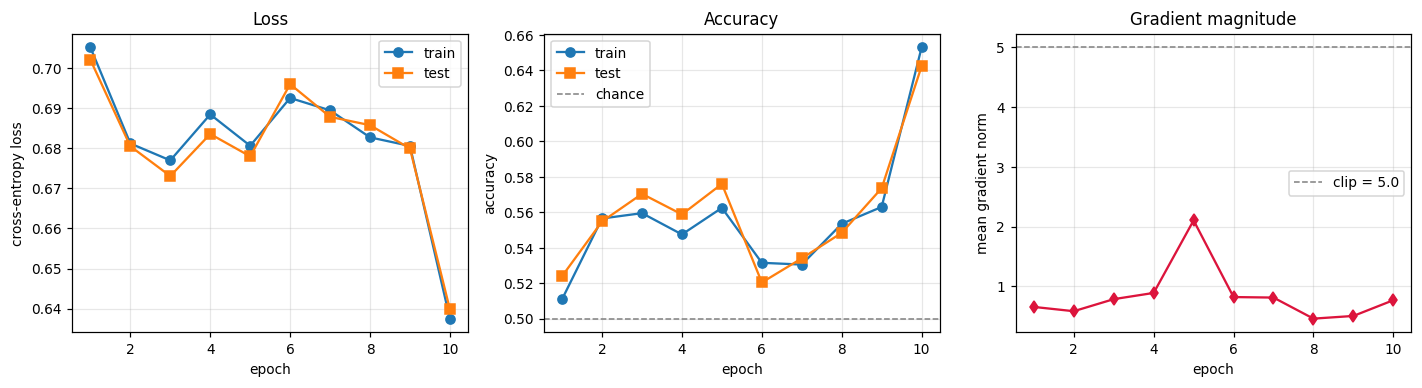

In [82]:
ep = np.arange(1, EPOCHS + 1)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))

ax[0].plot(ep, history["train_loss"], "o-", label="train")
ax[0].plot(ep, history["test_loss"],  "s-", label="test")
ax[0].set(xlabel="epoch", ylabel="cross-entropy loss", title="Loss")
ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(ep, history["train_acc"], "o-", label="train")
ax[1].plot(ep, history["test_acc"],  "s-", label="test")
ax[1].axhline(0.5, ls="--", c="grey", lw=1, label="chance")
ax[1].set(xlabel="epoch", ylabel="accuracy", title="Accuracy")
ax[1].legend(); ax[1].grid(alpha=.3)

ax[2].plot(ep, history["grad_norm"], "d-", color="crimson")
ax[2].axhline(CLIP_NORM, ls="--", c="grey", lw=1, label=f"clip = {CLIP_NORM}")
ax[2].set(xlabel="epoch", ylabel="mean gradient norm", title="Gradient magnitude")
ax[2].legend(); ax[2].grid(alpha=.3)

plt.tight_layout(); plt.show()

### 7.3 Reading the review one word at a time

Because the RNN produces a hidden state after *every* word, we can apply the output layer
$W_y$ at each step and watch its opinion form. Green means it's leaning positive, red negative.
Look for the moment a strong word flips the line.

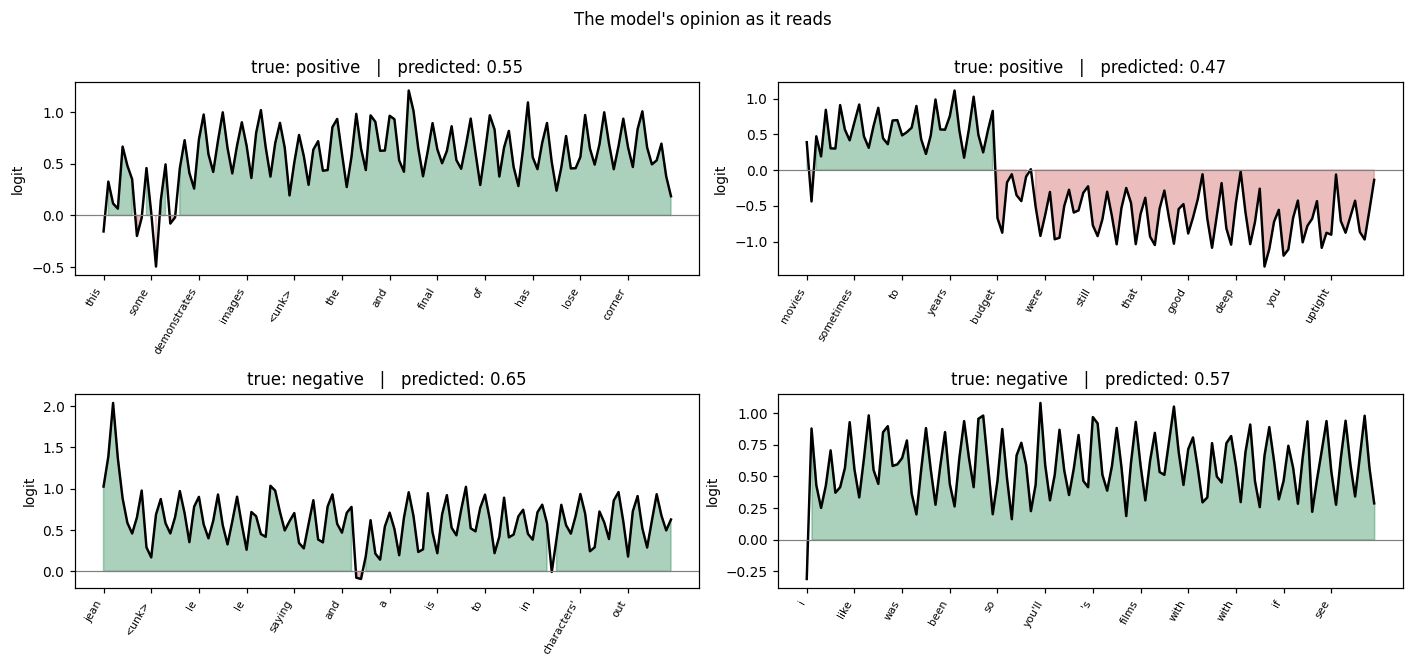

In [85]:
def running_sentiment(i):
    _, cache = forward(params, X_test[i:i+1], M_test[i:i+1], embedding_matrix)
    states = np.concatenate(cache[3][1:], axis=0)        # (T, H) state after each word
    scores = (states @ params["Wy"] + params["by"]).ravel()
    length = int(M_test[i].sum())
    words  = [itos[j] for j in X_test[i, :length]]
    return scores[:length], states[:length], words


picks = [0, 1, 2, 3]
fig, axes = plt.subplots(2, 2, figsize=(13, 6))

for ax_, i in zip(axes.ravel(), picks):
    scores, _, words = running_sentiment(i)
    ax_.plot(scores, lw=1.6, color="k")
    ax_.fill_between(range(len(scores)), 0, scores, where=scores >= 0, color="seagreen", alpha=.4)
    ax_.fill_between(range(len(scores)), 0, scores, where=scores <  0, color="indianred", alpha=.4)
    ax_.axhline(0, c="grey", lw=.8)

    step = max(1, len(words) // 12)                       # label a readable subset of words
    ticks = range(0, len(words), step)
    ax_.set_xticks(list(ticks))
    ax_.set_xticklabels([words[t] for t in ticks], rotation=60, ha="right", fontsize=7)

    true_lab = "positive" if y_test[i] else "negative"
    ax_.set(ylabel="logit", title=f"true: {true_lab}   |   predicted: {sigmoid(scores[-1]):.2f}")

plt.suptitle("The model's opinion as it reads", y=1.0)
plt.tight_layout(); plt.show()

### 7.4 Inside the hidden state

64 numbers changing over time. Each row is one hidden unit, each column one word.
Some units latch onto a value and hold it (memory), others flicker word to word.

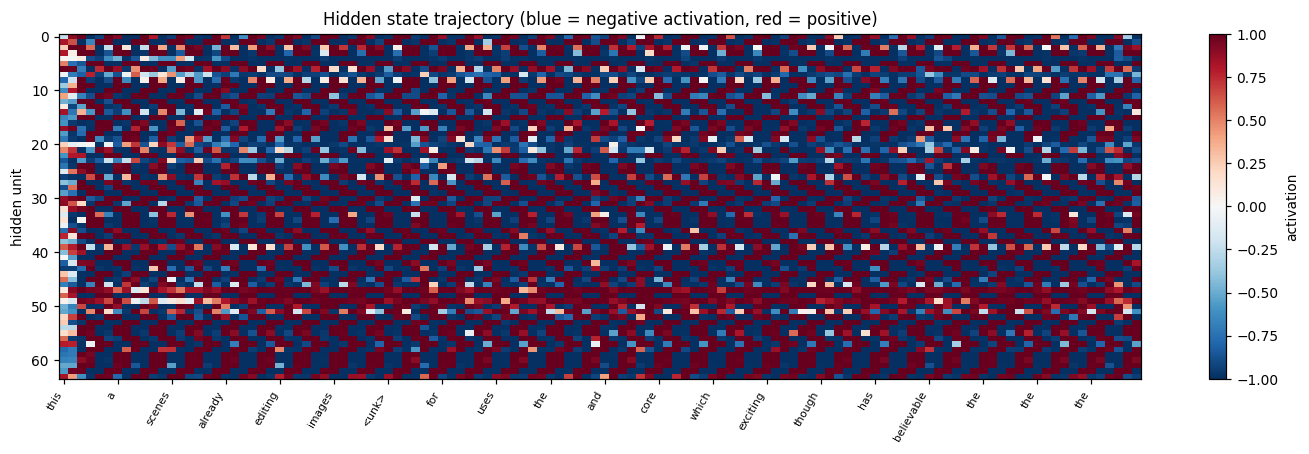

In [87]:
i = picks[0]
scores, states, words = running_sentiment(i)

fig, ax = plt.subplots(figsize=(13, 4.2))
im = ax.imshow(states.T, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
step = max(1, len(words) // 20)
ax.set_xticks(range(0, len(words), step))
ax.set_xticklabels([words[t] for t in range(0, len(words), step)], rotation=60, ha="right", fontsize=7)
ax.set(ylabel="hidden unit", title="Hidden state trajectory (blue = negative activation, red = positive)")
plt.colorbar(im, label="activation"); plt.tight_layout(); plt.show()

### 7.5 What does each word mean to the model?

A clean trick: feed the model a sequence of **exactly one word** and read the output logit.
That isolates each word's standalone contribution — no context, no interference. The model
never saw a one-word review during training, yet the vocabulary it discovered is obvious.

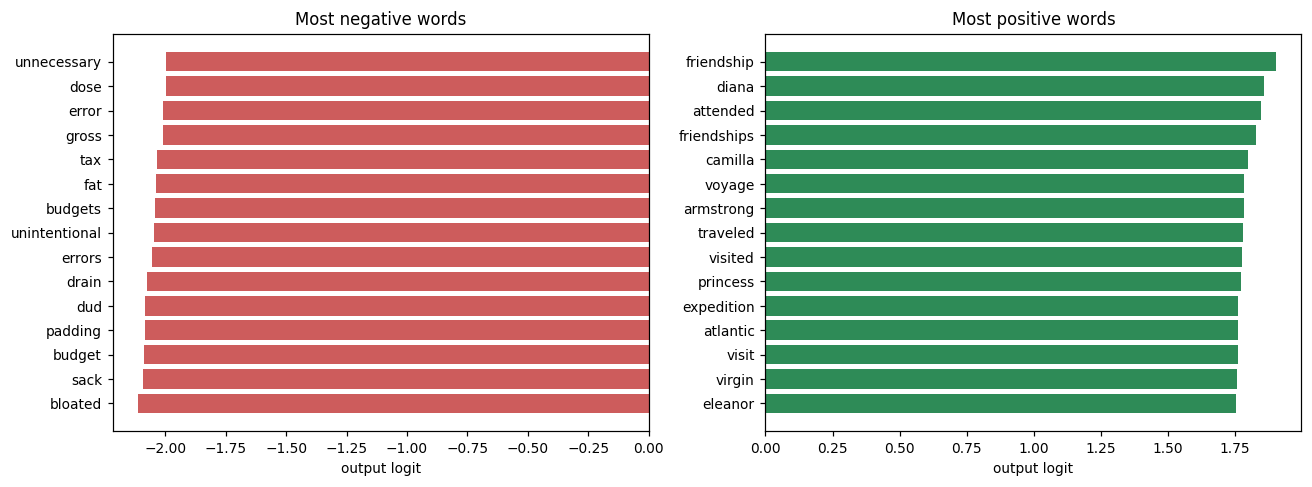

In [89]:
word_ids = np.arange(2, V)                     # skip <pad> and <unk>
single   = word_ids[:, None]
logits_w, _ = forward(params, single, np.ones_like(single, dtype=np.float64), embedding_matrix)

order = np.argsort(logits_w)
n_show = 15
neg_w = [(itos[word_ids[j]], logits_w[j]) for j in order[:n_show]]
pos_w = [(itos[word_ids[j]], logits_w[j]) for j in order[-n_show:]]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].barh([w for w, _ in neg_w], [s for _, s in neg_w], color="indianred")
ax[0].set(title="Most negative words", xlabel="output logit")
ax[1].barh([w for w, _ in pos_w], [s for _, s in pos_w], color="seagreen")
ax[1].set(title="Most positive words", xlabel="output logit")
plt.tight_layout(); plt.show()

### 7.6 Proof of the vanishing gradient

The theory said gradients shrink as they travel back through time. Let's measure it.

We take one batch, run BPTT, and record $\|\partial \mathcal{L} / \partial h_t\|$ at every step.
Plotted on a log scale, the decay is unmistakable — the gradient reaching the *first* word is
orders of magnitude smaller than the one at the last word.

**This is the single best motivation for LSTMs and GRUs**, and it's worth pausing on in class.

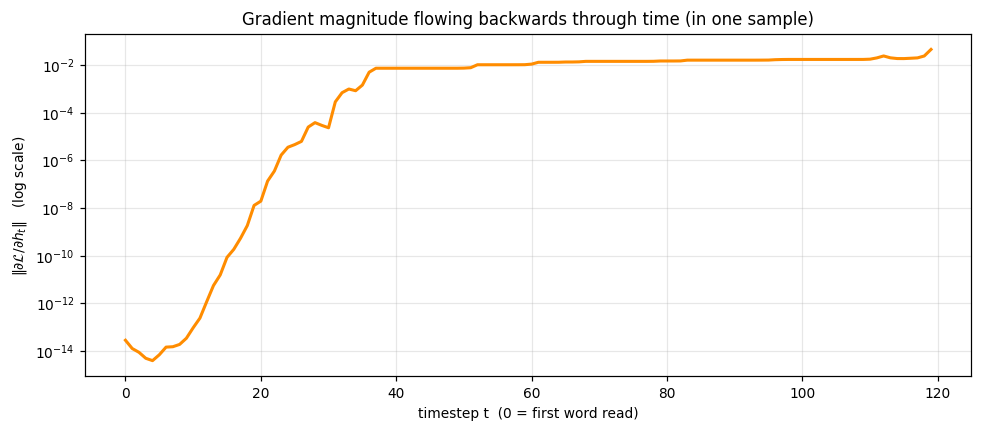

gradient at last word : 4.453e-02
gradient at first word: 2.783e-14
shrunk by a factor of : 1599850709794.9x


In [91]:
def gradient_flow(p, xb, mb, yb):
    logits, cache = forward(p, xb, mb, embedding_matrix)
    _, dlogits = bce_loss(logits, yb)
    _, mask_batch, emb, h_list, h_raw = cache
    T = xb.shape[1]

    dh = (dlogits[:, None]) @ p["Wy"].T
    norms = np.zeros(T)
    for t in reversed(range(T)):
        norms[t] = np.linalg.norm(dh)
        m = mask_batch[:, t][:, None]
        delta = (dh * m) * (1 - h_raw[t] ** 2)
        dh = dh * (1 - m) + delta @ p["Wh"].T
    return norms


flow = gradient_flow(params, X_train[:64], M_train[:64], y_train[:64])

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(flow, lw=2, color="darkorange")
ax.set(xlabel="timestep t  (0 = first word read)",
       ylabel=r"$\|\partial \mathcal{L} / \partial h_t\|$   (log scale)",
       title="Gradient magnitude flowing backwards through time (in one sample)")
ax.grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

print(f"gradient at last word : {flow[-1]:.3e}")
print(f"gradient at first word: {flow[0]:.3e}")
print(f"shrunk by a factor of : {flow[-1] / max(flow[0], 1e-30):.1f}x")

### 7.7 Try it on your own text

Edit the strings and re-run. Good place to hunt for failure cases — negation and sarcasm are where vanilla RNNs fall apart.

In [97]:
def predict(text):
    ids, mask = encode(tokenize(text))
    logits, _ = forward(params, np.array([ids]), np.array([mask]), embedding_matrix)
    return float(sigmoid(logits)[0])


samples = [
    "a beautiful, moving film with a wonderful cast and a brilliant script",
    "boring, painful and far too long. a complete waste of time",
    "i really wanted to love this movie but it was a mess",
    "weirdly, quite charming",
]

for s in samples:
    p_ = predict(s)
    bar = "#" * int(p_ * 30)
    print(f"{p_:.2f} |{bar:<30}| {'POS' if p_ > .5 else 'NEG'}  {s[:60]}")

0.69 |####################          | POS  a beautiful, moving film with a wonderful cast and a brillia
0.35 |##########                    | NEG  boring, painful and far too long. a complete waste of time
0.39 |###########                   | NEG  i really wanted to love this movie but it was a mess
0.57 |#################             | POS  weirdly, quite charming


### Exercises

1. **TF-IDF baseline.** Train logistic regression on TF-IDF embeddings. It will probably beat our model ! Discuss what that says about this dataset (and about when RNNs are worth it).
try it wallahi it's worth it, the thing is it costs nothing and you can run it literly on anything

2. **Truncated BPTT.** Stop the backward loop after 20 steps instead of all all time steps. How much
   accuracy do you lose? How much time do you save?
3. **Sequence length.** Set `MAX_LEN` to 30, then 300. Vanilla RNNs often do *worse* with
   longer sequences — explain why using plot 7.6.

# Lab cooked by Muhannad

<img src="https://i.imgur.com/VPQS9sz.jpeg" width="600" />